# A/B 测试框架

**业务问题**：某个改动是否真的带来了指标提升？还是随机波动？

**方法**：独立样本 t 检验 + 样本量估算 + 模拟实验

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import config
import sqlite3
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── 先把 seaborn 风格设好 ──
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

# ── 再设中文字体（必须放在 sns.set_style 之后！否则会被覆盖）──
import matplotlib.font_manager as fm
import glob
_cache_dir = matplotlib.get_cachedir()
for _f in glob.glob(os.path.join(_cache_dir, 'fontlist*.json')):
    try: os.remove(_f)
    except: pass
fm._load_fontmanager(try_read_cache=False)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Noto Sans SC']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

from src.analysis import ab_test_summary, required_sample_size

## 1. 模拟实验场景

假设我们在做一个优惠券实验：
- **对照组 A**：无优惠券，正常价格
- **实验组 B**：发放 10% 折扣券

我们想知道折扣券是否显著提升了客单价。

因为没有真实的 A/B 实验数据，我们从数据集中模拟：

In [2]:
# 从真实订单数据中抽取模拟 A/B 实验
conn = sqlite3.connect(config.DB_PATH)

orders = pd.read_sql("""
    SELECT o.order_id, o.customer_id, SUM(oi.price + oi.freight_value) AS order_value
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
        AND o.order_purchase_timestamp >= '2018-01-01'
    GROUP BY o.order_id
""", conn)
conn.close()

print(f'总订单数: {len(orders):,}')
print(f'客单价均值: R$ {orders["order_value"].mean():.2f}')
print(f'客单价标准差: R$ {orders["order_value"].std():.2f}')

总订单数: 52,783
客单价均值: R$ 160.12
客单价标准差: R$ 213.09


In [3]:
# 随机分配 A/B 组
np.random.seed(42)
n = len(orders)
assignment = np.random.binomial(1, 0.5, n)  # 50/50 split

group_a = orders[assignment == 0]['order_value']  # 对照组
group_b = orders[assignment == 1]['order_value']  # 实验组

# 给实验组加一个微小的提升效应（模拟优惠券效果）
effect = group_b.std() * 0.05  # 5% std 的提升
group_b = group_b + effect

print(f'对照组: n={len(group_a):,}, mean=R$ {group_a.mean():.2f}')
print(f'实验组: n={len(group_b):,}, mean=R$ {group_b.mean():.2f}')

对照组: n=26,390, mean=R$ 160.27
实验组: n=26,393, mean=R$ 170.89


  指标: 客单价 (R$)
  对照组均值: 160.2667
  实验组均值: 170.8896
  绝对差异: 10.6229
  相对提升: 6.63%
  95%_CI: [6.9871, 14.2587]
  t统计量: -5.7266
  p值: 0.0
  是否显著: 显著
  样本量_对照: 26390
  样本量_实验: 26393


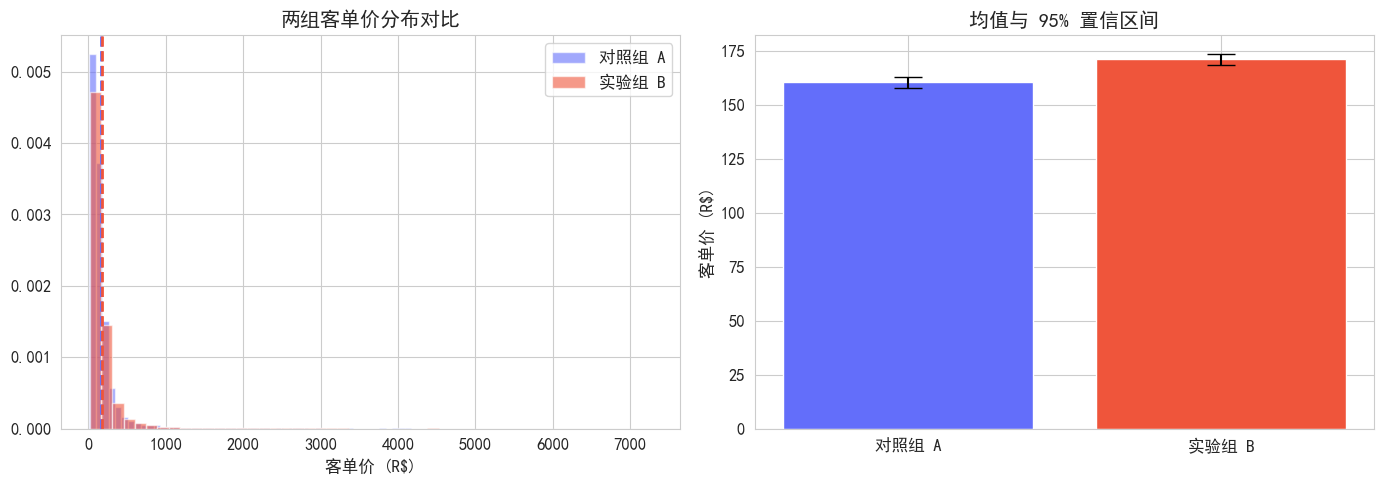

In [4]:
# 分布对比
from src.analysis import ab_test_summary

result = ab_test_summary(group_a, group_b, metric_name='客单价 (R$)')
for k, v in result.items():
    print(f'  {k}: {v}')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(group_a, bins=50, alpha=0.6, label='对照组 A', color='#636EFA', density=True)
axes[0].hist(group_b, bins=50, alpha=0.6, label='实验组 B', color='#EF553B', density=True)
axes[0].axvline(group_a.mean(), color='#636EFA', linewidth=2, linestyle='--')
axes[0].axvline(group_b.mean(), color='#EF553B', linewidth=2, linestyle='--')
axes[0].set_title('两组客单价分布对比')
axes[0].set_xlabel('客单价 (R$)')
axes[0].legend()

# 均值 + 95%CI
means = [group_a.mean(), group_b.mean()]
cis = [1.96 * group_a.std() / np.sqrt(len(group_a)),
       1.96 * group_b.std() / np.sqrt(len(group_b))]
axes[1].bar(['对照组 A', '实验组 B'], means, yerr=cis, color=['#636EFA', '#EF553B'], capsize=10)
axes[1].set_title('均值与 95% 置信区间')
axes[1].set_ylabel('客单价 (R$)')

plt.tight_layout()
plt.show()

## 2. 样本量计算

在实际工作中，**先算样本量再跑实验**是标准流程。
下面演示：如果想把转化率从 5% 提升到 5.5%，需要多少样本？

In [5]:
baseline = 0.050  # 基线转化率 5%
mde = 0.005       # 最小可检测效应 0.5%
power = 0.80      # 统计功效 80%

n_per_group = required_sample_size(baseline, mde, power)
print(f'基线转化率: {baseline*100}%')
print(f'最小可检测效应: {mde*100}%')
print(f'统计功效: {power*100}%')
print(f'--')
print(f'每组所需样本量: {n_per_group:,}')
print(f'总样本量: {n_per_group * 2:,}')

基线转化率: 5.0%
最小可检测效应: 0.5%
统计功效: 80.0%
--
每组所需样本量: 31,234
总样本量: 62,468


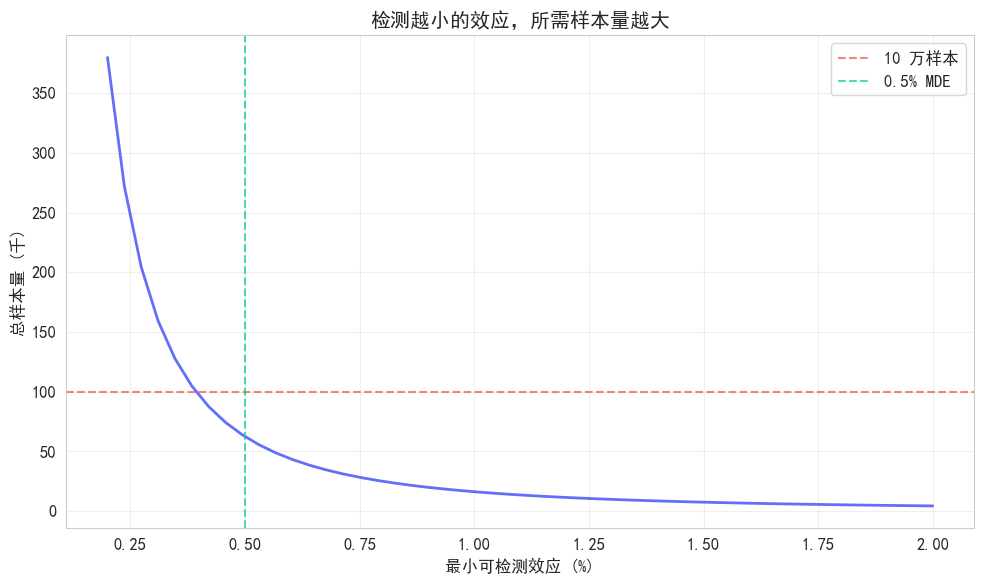

In [6]:
# 可视化：不同 MDE 下的样本量需求
mdes = np.linspace(0.002, 0.020, 50)
sample_sizes = [required_sample_size(baseline, m, power) * 2 for m in mdes]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mdes*100, [s/1000 for s in sample_sizes], linewidth=2, color='#636EFA')
ax.set_xlabel('最小可检测效应 (%)')
ax.set_ylabel('总样本量 (千)')
ax.set_title('检测越小的效应，所需样本量越大')
ax.axhline(y=100, color='#EF553B', linestyle='--', alpha=0.7, label='10 万样本')
ax.axvline(x=0.5, color='#00CC96', linestyle='--', alpha=0.7, label='0.5% MDE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 面试讲解要点

1. **为什么用 Welch's t-test 而不是 Student's t-test？**
   - 不假设两组方差相等，更稳健，适用于真实业务数据
2. **p 值 < 0.05 就说明实验成功了吗？**
   - 不，还需要检查效应量是否具有业务意义
   - 大样本下微小的差异也可能 p < 0.05，但不值得上线
3. **为什么 A/A 测试很重要？**
   - 验证分流系统的随机性，防止辛普森悖论
4. **样本量不够怎么办？**
   - 延长实验时间 / 放宽 MDE / 使用方差缩减技术（CUPED）